In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("Everything Working ✅")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\harsh mishra\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Everything Working ✅


In [2]:
import ultralytics

print(ultralytics.__version__)

8.4.84


In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math

from ultralytics import YOLO

In [4]:
model = YOLO("yolo11n.pt")

print("YOLO Loaded Successfully")

YOLO Loaded Successfully


In [5]:
video_path = "TownCentreXVID.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Video Not Found")
else:
    print("Video Loaded Successfully")

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Resolution : {width} x {height}")
print(f"FPS : {fps}")
print(f"Frames : {total_frames}")

Video Loaded Successfully
Resolution : 1920 x 1080
FPS : 25
Frames : 7502


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

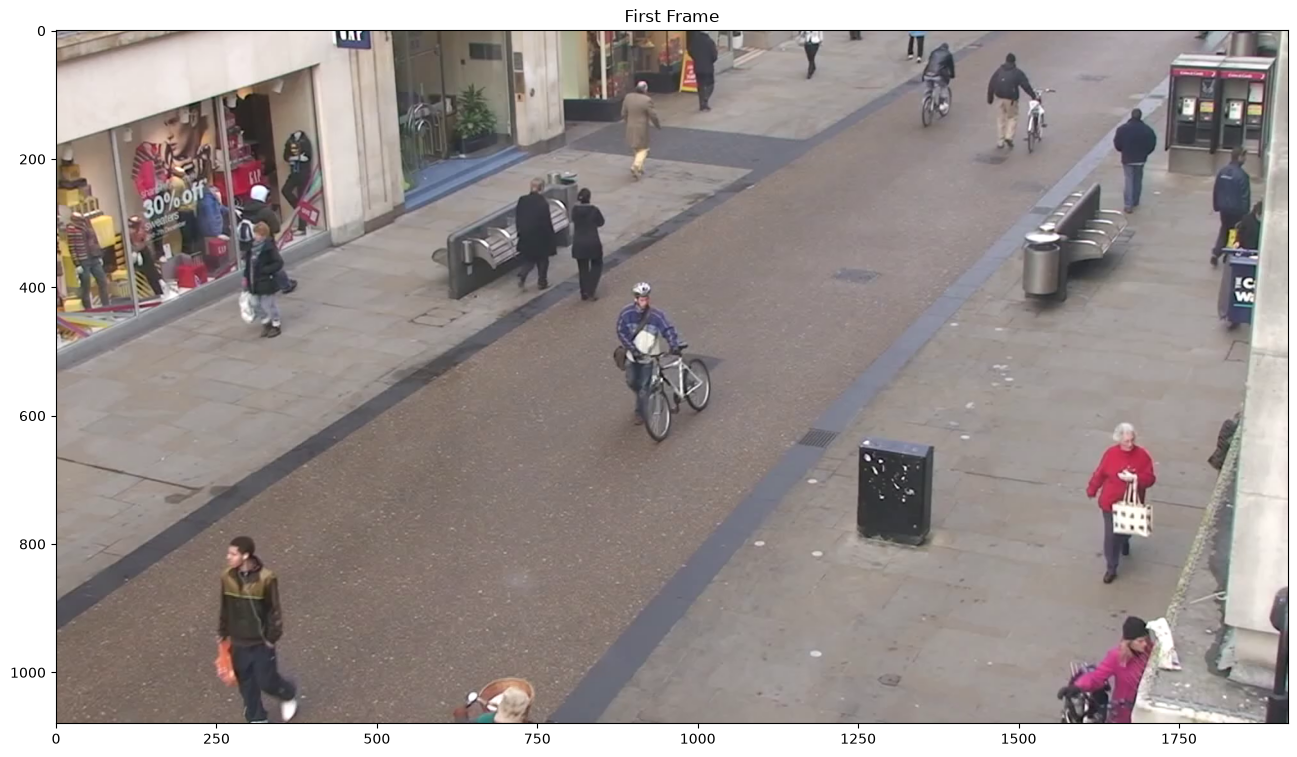

In [6]:
ret, frame = cap.read()

if not ret:
    print("Cannot Read First Frame")

plt.figure(figsize=(16,9))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("First Frame")
plt.axis("on")

In [10]:
polygon_points = []
display = frame.copy()

def mouse(event, x, y, flags, param):
    global display

    if event == cv2.EVENT_LBUTTONDOWN:

        if len(polygon_points) < 4:
            polygon_points.append((x, y))

            cv2.circle(display, (x, y), 5, (0,0,255), -1)

            if len(polygon_points) > 1:
                cv2.line(display,
                         polygon_points[-2],
                         polygon_points[-1],
                         (0,255,0),2)

            if len(polygon_points) == 4:
                cv2.line(display,
                         polygon_points[3],
                         polygon_points[0],
                         (0,255,0),2)

            cv2.imshow("Polygon", display)

cv2.imshow("Polygon", display)

cv2.setMouseCallback("Polygon", mouse)

cv2.waitKey(0)

cv2.destroyAllWindows()

print(polygon_points)

[(795, 179), (877, 140), (1169, 171), (1085, 218)]


In [11]:
polygon = np.array([
    [877, 140],   # Top Left
    [1169, 171],  # Top Right
    [1085, 218],  # Bottom Right
    [795, 179]    # Bottom Left
], dtype=np.int32)

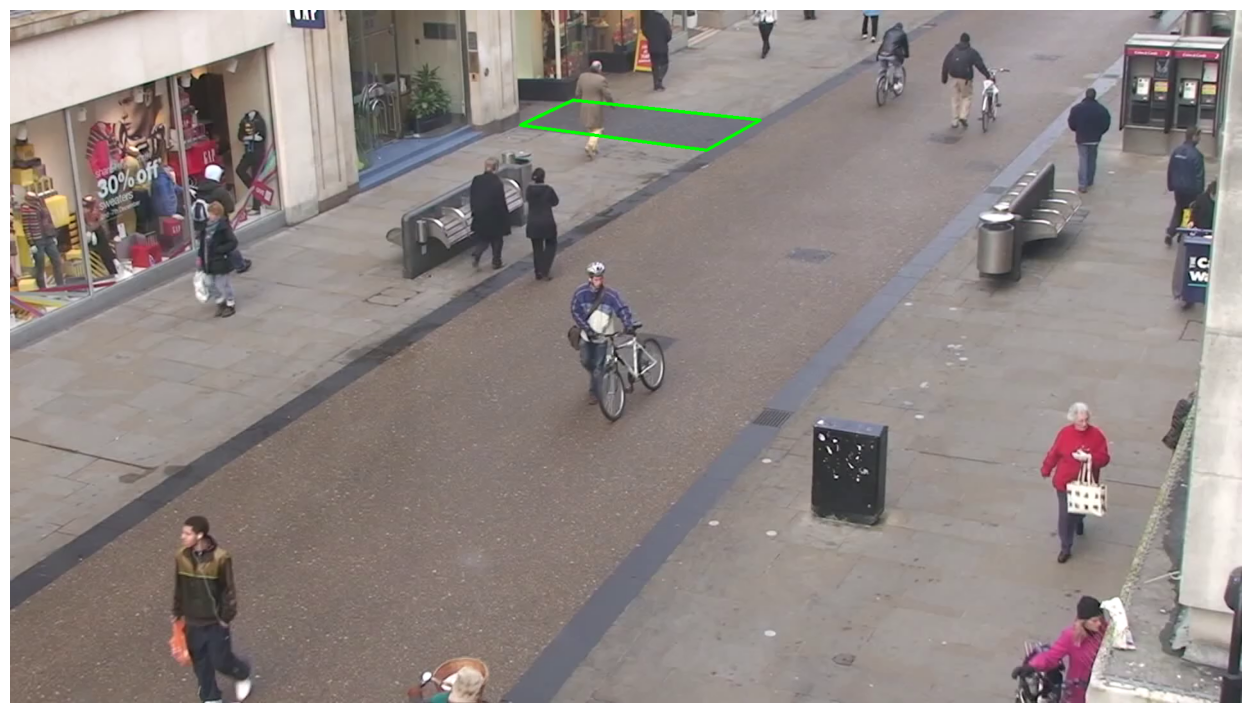

In [12]:
temp = frame.copy()

cv2.polylines(temp, [polygon], True, (0,255,0), 3)

plt.figure(figsize=(16,9))
plt.imshow(cv2.cvtColor(temp, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [13]:
cap.release()

cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

In [19]:
from shapely.geometry import Point, Polygon

frame_no = 0

left_to_right = 0

previous_centers = {}

counted_ids = set()

track_history = {}

csv_data = []

poly = Polygon(polygon)

In [26]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_no += 1

    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        classes=[0],
        conf=0.35,
        verbose=False
    )

    display = frame.copy()

    cv2.polylines(display, [polygon], True, (0,255,0), 3)

    if results[0].boxes.id is None:
        out.write(display)
        continue

    boxes = results[0].boxes.xyxy.cpu().numpy()
    ids = results[0].boxes.id.cpu().numpy().astype(int)

    for box, track_id in zip(boxes, ids):

        x1, y1, x2, y2 = map(int, box)

        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2

        center = (cx, cy)

        cv2.rectangle(display, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.circle(display, center, 4, (0,0,255), -1)
        cv2.putText(display, f"ID {track_id}", (x1,y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,0,0),2)

        if track_id not in previous_centers:
            previous_centers[track_id]=center
            continue

        prev=previous_centers[track_id]
        previous_centers[track_id]=center

        if track_id in counted_ids:
            continue

        inside_prev = poly.contains(Point(prev))
        inside_now = poly.contains(Point(center))

        if inside_prev and not inside_now and center[0] > prev[0]:
            left_to_right += 1
            counted_ids.add(track_id)
            csv_data.append({
                "Frame": frame_no,
                "Track_ID": int(track_id),
                "Direction":"Left_to_Right"
            })

    cv2.putText(display,
                f"Left -> Right : {left_to_right}",
                (20,40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0,0,255),
                3)

    out.write(display)
    cv2.imshow("People Counter", display)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break


In [29]:
cap.release()
out.release()
cv2.destroyAllWindows()

In [30]:
import pandas as pd

df = pd.DataFrame(csv_data)

df.to_csv("People_Count.csv", index=False)

print("=" * 50)
print("Processing Completed")
print("=" * 50)
print(f"Total Left → Right Count : {left_to_right}")
print(f"CSV Records : {len(df)}")
print("CSV Saved : People_Count.csv")
print("Output Video : output.mp4")
print("=" * 50)

Processing Completed
Total Left → Right Count : 0
CSV Records : 0
CSV Saved : People_Count.csv
Output Video : output.mp4
